# Analiza języka Adama Mickiewicza

Analiza statystyczna prac Adama Mickiewicza (Pan Tadeusz) w różnych wydaniach.

# Import bibliotek, funkcji oraz danych.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from analyzer.dictionary import (read_dictionary, calculate_dictionary_statistics, )
from analyzer.works import (read_works, calculate_work_statistics, calculate_total_statistics, get_work_frequencies, compare_works, )
from analyzer.analysis import find_unknown_words

In [6]:
from pathlib import Path

ROOT = Path("..")
DATA = ROOT / "data"

dictionary_path = DATA / "odm.txt"
WORKS = [DATA / "Pan_Tadeusz.txt", DATA / "Pan_Tedeusz.txt",]

# Analiza słownika

In [4]:
dictionary_lines, dictionary_words = read_dictionary(dictionary_path)

dictionary_statistics = calculate_dictionary_statistics(dictionary_lines, dictionary_words,)

pd.Series(dictionary_statistics)

num_lines                                                      236006
num_words                                                     4760935
unique_num_words                                              4521735
top_words           [(kurze, 11), (ruski, 9), (gotów, 8), (kicie, ...
polish_letters      [(i, 5476160), (a, 5167874), (o, 4785291), (e,...
other_characters    [(-, 31795), ( , 15499), (v, 10713), (', 5982)...
dtype: object

Powyżej przedstawiono podstawowe statystyki dotyczące liczby wierszy, liczby słów oraz liczby unikalnych form.

# Analiza utworów 

In [7]:
works = read_works(WORKS)

for path, (lines, words) in works.items():
    print(path.name)
    display(pd.Series(calculate_work_statistics(lines, words)))

total_statistics = calculate_total_statistics(works)

pd.Series(total_statistics)

Pan_Tadeusz.txt


num_lines                                                        4994
num_words                                                       31791
unique_num_words                                                11232
top_words           [(i, 1008), (w, 888), (się, 705), (na, 601), (...
polish_letters      [(a, 14603), (i, 14009), (e, 11071), (o, 10998...
other_characters                                     [(v, 6), (x, 6)]
dtype: object

Pan_Tedeusz.txt


num_lines                                                        5772
num_words                                                       36456
unique_num_words                                                12312
top_words           [(i, 1046), (w, 994), (się, 731), (na, 623), (...
polish_letters      [(a, 16422), (i, 15881), (e, 13489), (o, 13013...
other_characters                         [(v, 122), (x, 39), (q, 11)]
dtype: object

num_lines                                                       10766
num_words                                                       68247
unique_num_words                                                12312
top_words           [(i, 2054), (w, 1882), (się, 1436), (na, 1224)...
polish_letters      [(a, 31025), (i, 29890), (e, 24560), (o, 24011...
other_characters                         [(v, 128), (x, 45), (q, 11)]
dtype: object

Powyższe zestawienie pokazuje statystyki dla każdego dzieła osobno oraz dla utworów razem.

# Najczęściej występujące słowa

In [8]:
frequencies = get_work_frequencies(works, limit=20)

for work, freq in frequencies.items():
    print(work.name)
    display(
        pd.DataFrame(freq, columns=["Słowo", "Liczba wystąpień"])
    )

Pan_Tadeusz.txt


,Słowo,Liczba wystąpień
0,i,1008
1,w,888
2,się,705
3,na,601
4,j,542
5,z,402
6,jak,302
7,do,268
8,s,256
9,że,246


Pan_Tedeusz.txt


,Słowo,Liczba wystąpień
0,i,1046
1,w,994
2,się,731
3,na,623
4,j,571
5,z,418
6,jak,308
7,to,299
8,do,296
9,a,283


Wykres najczęstszych słów:

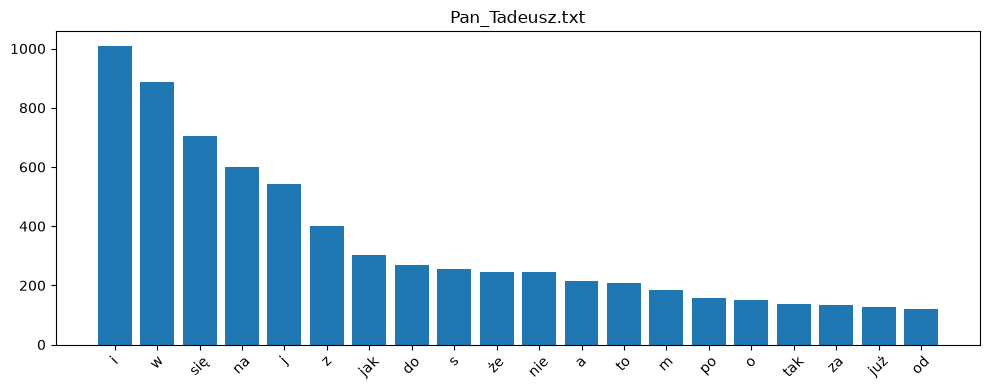

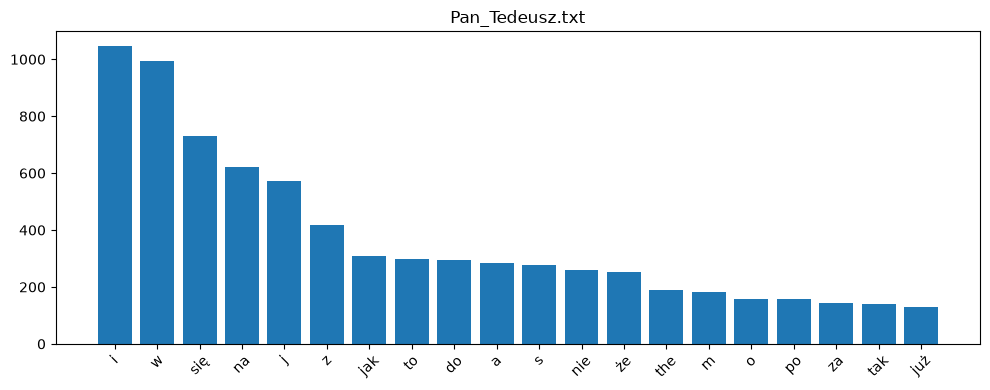

In [9]:
for work, freq in frequencies.items():
    df = pd.DataFrame(freq, columns=["Słowo", "Liczba"])

    plt.figure(figsize=(10,4))
    plt.bar(df["Słowo"], df["Liczba"])
    plt.xticks(rotation=45)
    plt.title(work.name)
    plt.tight_layout()
    plt.show()

# Słowa, które nie występują w słowniku

In [10]:
for path, (_, words) in works.items():
    unknown = find_unknown_words(words, dictionary_words)

    print(path.name)

    display( pd.DataFrame(unknown[:20], columns=["Słowo", "Liczba wystąpień"]))


Pan_Tadeusz.txt


,Słowo,Liczba wystąpień
0,assessor,25
1,nakształt,15
2,któr,14
3,zwolna,14
4,nakoniec,13
5,wi,13
6,jedn,11
7,wt,11
8,cał,9
9,mni,9


Pan_Tedeusz.txt


,Słowo,Liczba wystąpień
0,the,190
1,of,125
2,project,89
3,you,75
4,with,47
5,str,45
6,this,45
7,work,45
8,works,32
9,electronic,27


Większość słów spoza słownika stanowią formy archaiczne, błędne wyrazy oraz angielskie słowa (których oczywiście w polskim słowniku nie spotkamy).

# Porównanie podobieństw utworów

Porównanie utworów zostało wykonane na podstawie częstości występowania wszystkich słów.

Dla każdego tekstu wyznaczono znormalizowany wektor częstości słów, a następnie obliczono podobieństwo cosinusowe pomiędzy parami utworów. Wynik został przeskalowany do zakresu od 0 do 100, gdzie 100 oznacza identyczny rozkład słów.

In [11]:
similarity = compare_works(works)

similarity

,Pan_Tadeusz.txt,Pan_Tedeusz.txt
Pan_Tadeusz.txt,100.000000,98.583138
Pan_Tedeusz.txt,98.583138,100.000000


Z powyższej wartości widać, że dzieła są bardzo zbliżone do siebie co nie powinno nikogo dziwić - w końcu porównujemy tą samą powieść w różnych wydaniach!

# Wnioski

- Analizowany słownik zawiera ponad **4,7 miliona wyrazów**, z czego ponad **4,5 miliona stanowią unikalne formy**, co świadczy o bardzo bogatym zasobie fleksyjnym języka polskiego.

- Statystyki utworów pokazują, że oba analizowane wydania *Pana Tadeusza* mają bardzo zbliżoną liczbę słów oraz podobną strukturę tekstu.

- Najczęściej występujące słowa to przede wszystkim wyrazy funkcyjne (np. spójniki i przyimki)

- Rozkład częstości słów odpowiada typowej charakterystyce języka naturalnego – niewielka liczba słów występuje bardzo często, natomiast większość pojawia się sporadycznie.

- Wysoka zgodność słownictwa między analizowanymi wydaniami wskazuje, że różnice edytorskie mają niewielki wpływ na ogólny rozkład użytych słów.

- Miara podobieństwa wynosząca około **98,6%** potwierdza, że oba teksty są niemal identyczne pod względem częstości występowania słów.

- Przeprowadzona analiza pokazuje, że proste metody statystyczne pozwalają skutecznie porównywać teksty oraz identyfikować różnice pomiędzy ich wersjami.